# Phân tích khám phá dữ liệu (EDA)
Bộ dữ liệu: **Bike Sharing Dataset** — file `hour.csv`

## Giới thiệu bộ dữ liệu Bike Sharing

Bộ dữ liệu [**Bike Sharing Dataset**](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) ghi nhận thông tin thuê xe đạp tự động từ hệ thống Capital Bikeshare, Washington D.C., Mỹ trong hai năm 2011-2012. Dữ liệu được tổng hợp theo giờ và ngày, có tích hợp thêm thông tin thời tiết và mùa.

**Thông tin chi tiết:**
* **Tập dữ liệu sử dụng:** `hour.csv` với 17.379 mẫu.
* **Biến mục tiêu (Target):** `cnt` (tổng số lượng xe đạp được thuê).
* **Các đặc trưng (Features):** Bao gồm các biến về thời gian (giờ, ngày, tháng, mùa, ngày lễ) và các chỉ số thời tiết (nhiệt độ `temp`, độ ẩm `hum`, tốc độ gió `windspeed`).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Xác định ROOT: thư mục chứa 'data/'
try:
    ROOT = Path(__file__).resolve().parent.parent
except NameError:
    cwd = Path.cwd()
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        if (candidate / "data").exists():
            ROOT = candidate
            break
    else:
        raise FileNotFoundError(f"Không tìm thấy thư mục 'data/' từ {cwd}")

DATA_DIR = ROOT / "data"
IMGS_DIR = Path(Path.cwd()) / "imgs"
IMGS_DIR.mkdir(exist_ok=True)

print(f"ROOT     : {ROOT}")
print(f"DATA_DIR : {DATA_DIR}")
print(f"IMGS_DIR : {IMGS_DIR}")
assert (DATA_DIR / "hour.csv").exists(), f"Không tìm thấy {DATA_DIR / 'hour.csv'}"

plt.rcParams["figure.dpi"] = 120

ROOT     : /home/lesliu/Documents/school/25_26_Semester_2/intro2ml/lab1
DATA_DIR : /home/lesliu/Documents/school/25_26_Semester_2/intro2ml/lab1/data
IMGS_DIR : /home/lesliu/Documents/school/25_26_Semester_2/intro2ml/lab1/code/Part1_Regression/imgs


## 1. Đọc và tổng quan dữ liệu

In [2]:
df = pd.read_csv(DATA_DIR / "hour.csv")
print(f"Kích thước: {df.shape[0]} mẫu, {df.shape[1]} cột")
df.head()

Kích thước: 17379 mẫu, 17 cột


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Kiểm tra giá trị thiếu:

In [4]:
missing = df.isnull().sum()
print("Số giá trị thiếu theo cột:")
print(missing[missing > 0] if missing.any() else "Không có giá trị thiếu.")

Số giá trị thiếu theo cột:
Không có giá trị thiếu.


**Nhận xét**

- Các cột dạng categorical: `season`, `yr`, `mnth`, `hr`, `weekday`, `weathersit`, `holiday`, `workingday`. Trong đó:
    - Ta sẽ xem `weathersit` là ordinal, vì các mức thời tiết có thứ tự về mức độ xấu dần (1: trời đẹp, 2: có mây, 3: mưa nhẹ, 4: mưa nặng).
    - Còn lại là nominal do không rõ thứ tự giá trị.
- Các cột dạng numerical: `temp`, `atemp`, `hum`, `windspeed`, `casual`, `registered`, `cnt`
- Không có giá trị thiếu (missing values) nào trong tập dữ liệu.

## 1.5. Các cột không cần thiết
Dựa vào mô tả của tác giả về bộ dữ liệu, ta sẽ không sử dụng các cột `casual` và `registered` vì chúng chỉ là thành phần của biến mục tiêu `cnt` và không có ý nghĩa dự đoán trong thực tế. Do đó, nếu đưa các cột này vào mô hình, mô hình sẽ vô tình sử dụng thông tin của biến mục tiêu để dự đoán chính nó. Điều này gây ra **data leakage**, khiến kết quả đánh giá mô hình không còn phản ánh đúng khả năng dự đoán trong thực tế.

Ngoài ra, cột `instant` chỉ đóng vai trò là chỉ số dòng (index) của dữ liệu và không mang thông tin có giá trị cho việc dự đoán.

Cột `dteday` biểu diễn ngày tháng dưới dạng timestamp, tuy nhiên các đặc trưng thời gian quan trọng như yr, mnth, hr, weekday và season đã được tách sẵn trong bộ dữ liệu. Vì vậy, việc giữ lại dteday là không cần thiết cho mô hình hồi quy.

## 2. Thống kê mô tả

In [5]:
FEATURES = ["temp", "atemp", "hum", "windspeed",
            "season", "yr", "mnth", "hr",
            "holiday", "weekday", "workingday", "weathersit"]
TARGET = "cnt"

stat = df[FEATURES + [TARGET]].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]
stat.columns = ["Trung bình", "Độ lệch chuẩn", "Min", "Q1", "Trung vị", "Q3", "Max"]
stat.round(4)

,Trung bình,Độ lệch chuẩn,Min,Q1,Trung vị,Q3,Max
temp,0.4970,0.1926,0.02,0.3400,0.5000,0.6600,1.0000
atemp,0.4758,0.1719,0.00,0.3333,0.4848,0.6212,1.0000
hum,0.6272,0.1929,0.00,0.4800,0.6300,0.7800,1.0000
windspeed,0.1901,0.1223,0.00,0.1045,0.1940,0.2537,0.8507
season,2.5016,1.1069,1.00,2.0000,3.0000,3.0000,4.0000
yr,0.5026,0.5000,0.00,0.0000,1.0000,1.0000,1.0000
mnth,6.5378,3.4388,1.00,4.0000,7.0000,10.0000,12.0000
hr,11.5468,6.9144,0.00,6.0000,12.0000,18.0000,23.0000
holiday,0.0288,0.1672,0.00,0.0000,0.0000,0.0000,1.0000
weekday,3.0037,2.0058,0.00,1.0000,3.0000,5.0000,6.0000


## 3. Phân bố biến mục tiêu `cnt`

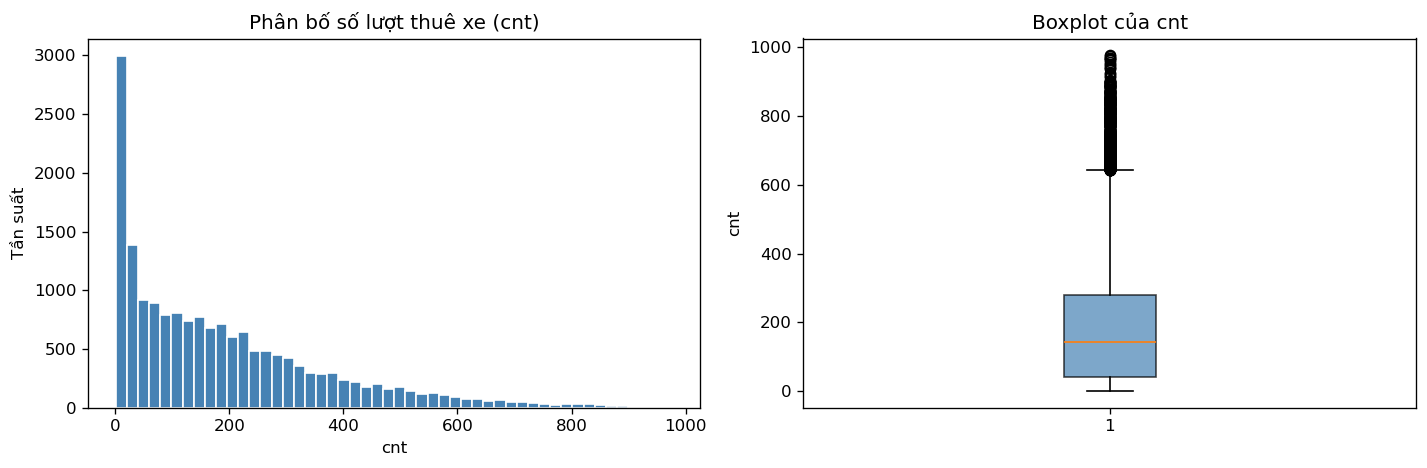

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df[TARGET], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Phân bố số lượt thuê xe (cnt)")
axes[0].set_xlabel("cnt")
axes[0].set_ylabel("Tần suất")

# Boxplot
axes[1].boxplot(df[TARGET], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_title("Boxplot của cnt")
axes[1].set_ylabel("cnt")

plt.tight_layout()
plt.savefig(IMGS_DIR / "cnt_distribution.png")
plt.show()

**Nhận xét**

- Histogram cho thấy phân bố `cnt` **lệch phải mạnh**: đỉnh ở bin đầu (cnt thấp ~0–20) rồi giảm dần, đuôi kéo dài tới ~977.  
- Boxplot: trung vị = 142, Q1 = 40, Q3 = 281 — khoảng IQR = 241, trong khi trung bình = 189 >> trung vị.  
- Phần lớn giờ trong ngày có dưới 200 lượt thuê; chỉ một thiểu số giờ cao điểm đạt trên 600.

## 4. Phân tích tương quan

### `cnt` với các biến numeric

Với các biến numeric, ta sử dụng **hệ số tương quan Pearson** để đo lường mối quan hệ tuyến tính giữa `cnt` và từng biến numeric.

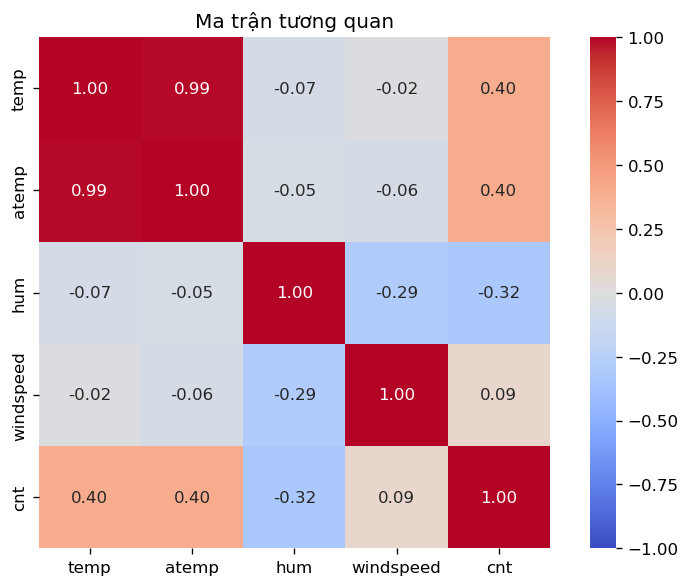

In [7]:
num_cols = ["temp", "atemp", "hum", "windspeed", TARGET]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Ma trận tương quan")
plt.tight_layout()
plt.savefig(IMGS_DIR / "correlation_matrix.png")
plt.show()

**Nhận xét**

- `temp` và `atemp` gần như đồng nhất (r = 0.99) → **đa cộng tuyến cao**, nên chọn một trong hai khi xây dựng mô hình.
- Cả `temp` và `atemp` đều có tương quan dương vừa phải với `cnt` (r = 0.40).
- `hum` có tương quan âm vừa phải với `cnt` (r = −0.32): độ ẩm cao làm giảm nhu cầu thuê xe.
- `windspeed` gần như không có tương quan tuyến tính với `cnt` (r = 0.09).

### `cnt` với các biến nominal

Với các biến nominal, ta sử dụng Correlation Ratio ($\eta$) để đo mức độ liên hệ giữa biến phân loại và biến mục tiêu liên tục `cnt`. Chỉ số này dựa trên nguyên lý của ANOVA, đo lường mức độ mà sự khác biệt giữa các nhóm category có thể giải thích phương sai của biến mục tiêu.

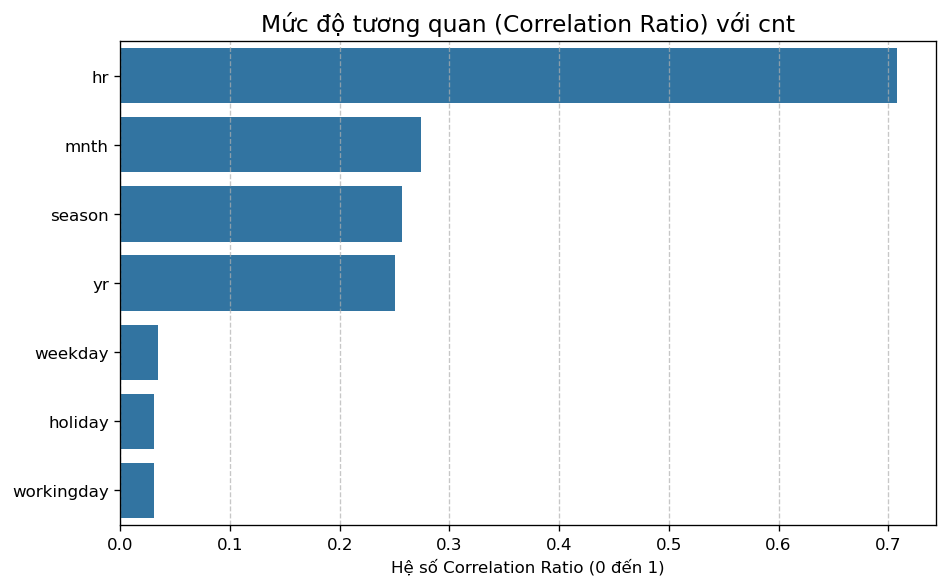

In [8]:
# Hàm tính Correlation Ratio (Categorical vs Continuous)
def correlation_ratio(categories, measurements):
    fcat, _ = pd.factorize(categories)
    cat_num = np.max(fcat) + 1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)
    for i in range(0, cat_num):
        cat_measures = measurements[np.argwhere(fcat == i).flatten()]
        n_array[i] = len(cat_measures)
        y_avg_array[i] = np.average(cat_measures)
    y_total_avg = np.sum(np.multiply(y_avg_array, n_array)) / np.sum(n_array)
    numerator = np.sum(np.multiply(n_array, np.power(np.subtract(y_avg_array, y_total_avg), 2)))
    denominator = np.sum(np.power(np.subtract(measurements, y_total_avg), 2))
    return 0.0 if numerator == 0 else np.sqrt(numerator / denominator)

cat_cols = ['season', 'yr', 'mnth', 'hr', 'weekday', 'holiday', 'workingday']
target = 'cnt'

# Tính hệ số cho từng biến
eta_results = {col: correlation_ratio(df[col], df[target]) for col in cat_cols}

# Chuyển thành DataFrame và sắp xếp
df_eta = pd.DataFrame(list(eta_results.items()), columns=['Biến', 'Correlation_Ratio'])
df_eta = df_eta.sort_values(by='Correlation_Ratio', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
sns.barplot(x='Correlation_Ratio', y='Biến', data=df_eta)
plt.title(f"Mức độ tương quan (Correlation Ratio) với {target}", fontsize=14)
plt.xlabel("Hệ số Correlation Ratio (0 đến 1)")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Nhận xét**

* `hr` có **mức liên hệ mạnh nhất** với `cnt` (η ≈ 0.71) → thời điểm trong ngày ảnh hưởng rất lớn đến số lượng xe được thuê.
* `mnth`, `season`, và `yr` có **mức liên hệ trung bình** với `cnt` (η ≈ 0.25–0.27) → nhu cầu thuê xe thay đổi theo **mùa và thời gian trong năm**.
* `weekday`, `holiday`, và `workingday` có **mức liên hệ rất yếu** với `cnt` (η < 0.05) → các yếu tố này ít giải thích được sự biến thiên của số lượng xe thuê.

### `cnt` với các biến ordinal

Với các biến ordinal, ta sử dụng Spearman's rank correlation coefficient để đo mức độ tương quan với biến mục tiêu `cnt`. Phương pháp này dựa trên thứ hạng của dữ liệu thay vì giá trị tuyệt đối, do đó phù hợp với các biến có thứ tự nhưng không đảm bảo khoảng cách giữa các mức là đồng đều.

            Spearman r   p-value Có ý nghĩa (p<0.05)
Biến                                                
weathersit     -0.1263  1.06e-62                   ✓


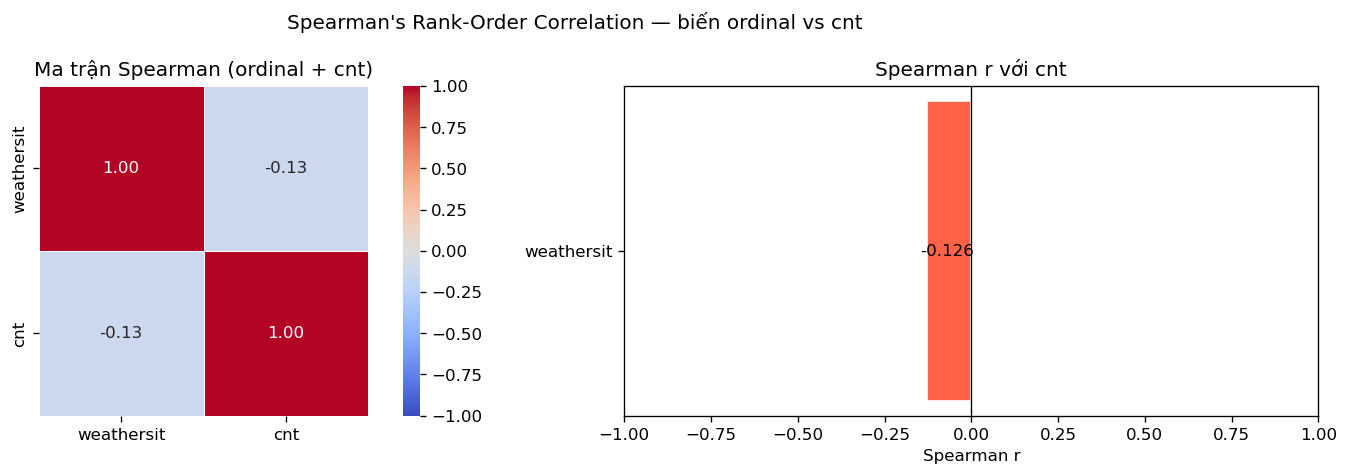

In [9]:
ordinal_vars = ["weathersit"]

# --- Bảng hệ số Spearman và p-value ---
rows = []
for var in ordinal_vars:
    r, p = stats.spearmanr(df[var], df[TARGET])
    rows.append({"Biến": var, "Spearman r": round(r, 4), "p-value": f"{p:.2e}",
                 "Có ý nghĩa (p<0.05)": "✓" if p < 0.05 else "✗"})
spearman_df = pd.DataFrame(rows).set_index("Biến")
print(spearman_df.to_string())

# --- Heatmap ma trận Spearman + Bar chart ---
spearman_mat = df[ordinal_vars + [TARGET]].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(spearman_mat, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title("Ma trận Spearman (ordinal + cnt)")

r_vals = [stats.spearmanr(df[v], df[TARGET])[0] for v in ordinal_vars]
colors = ["steelblue" if r > 0 else "tomato" for r in r_vals]
axes[1].barh(ordinal_vars, r_vals, color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlim(-1, 1)
axes[1].set_xlabel("Spearman r")
axes[1].set_title("Spearman r với cnt")
for i, r in enumerate(r_vals):
    axes[1].text(r + 0.02 * np.sign(r), i, f"{r:.3f}", va="center", fontsize=10)

plt.suptitle("Spearman's Rank-Order Correlation — biến ordinal vs cnt", fontsize=12)
plt.tight_layout()
plt.savefig(IMGS_DIR / "spearman_ordinal.png", bbox_inches="tight")
plt.show()

**Nhận xét**

* `weathersit` có **tương quan âm rất yếu** với `cnt` theo **Spearman's rank correlation coefficient** (r ≈ −0.13).
* Điều này cho thấy khi **mức độ thời tiết xấu tăng** (ví dụ từ trời đẹp → mưa), **số lượng xe thuê có xu hướng giảm**.
* Tuy nhiên, độ lớn của hệ số khá nhỏ (|r| < 0.2) → **mối quan hệ đơn điệu yếu**, tức là `weathersit` chỉ giải thích được một phần rất nhỏ sự biến thiên của `cnt`.
* Vì vậy, biến này **có ảnh hưởng nhưng không phải yếu tố quyết định mạnh** đến nhu cầu thuê xe.

## 5. `cnt` và các biến thời tiết (numeric)

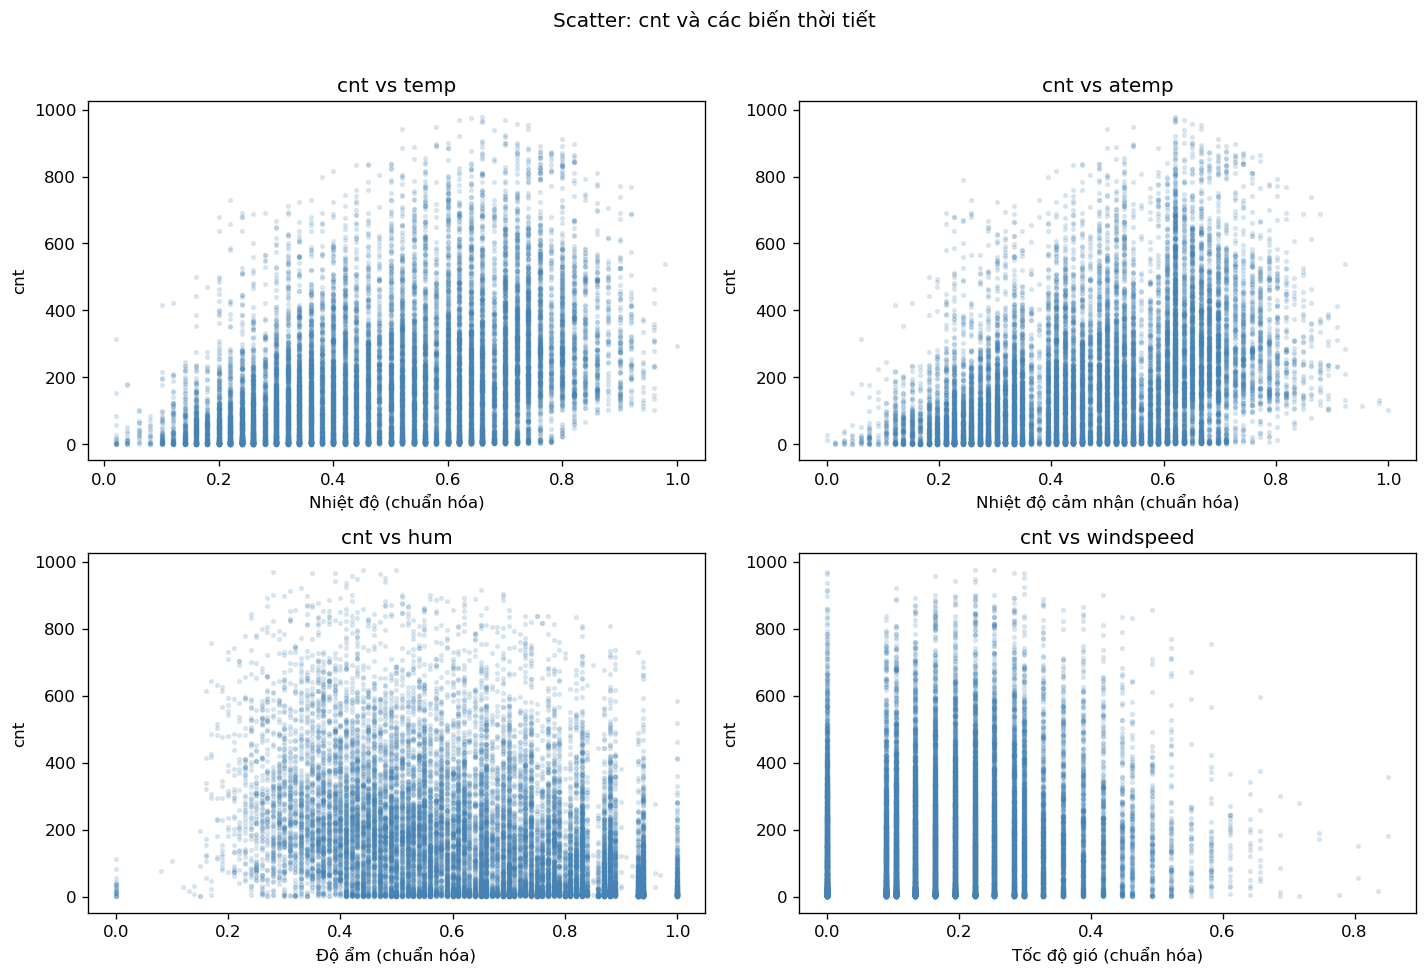

In [10]:
weather_vars = ["temp", "atemp", "hum", "windspeed"]
labels = {
    "temp": "Nhiệt độ (chuẩn hóa)",
    "atemp": "Nhiệt độ cảm nhận (chuẩn hóa)",
    "hum": "Độ ẩm (chuẩn hóa)",
    "windspeed": "Tốc độ gió (chuẩn hóa)",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.flat, weather_vars):
    ax.scatter(df[var], df[TARGET], alpha=0.15, s=5, color="steelblue")
    ax.set_xlabel(labels[var])
    ax.set_ylabel("cnt")
    ax.set_title(f"cnt vs {var}")

plt.suptitle("Scatter: cnt và các biến thời tiết", y=1.01)
plt.tight_layout()
plt.savefig(IMGS_DIR / "scatter_weather_cnt.png", bbox_inches="tight")
plt.show()

**Nhận xét**

- `temp` và `atemp` (r = 0.40): xu hướng tăng rõ nhưng scatter rất rộng → quan hệ có thể phi tuyến, nhiều yếu tố khác cùng tác động.
- `hum` (r = −0.32): khi độ ẩm vượt ~0.8, `cnt` giảm mạnh và đột ngột — ảnh hưởng rõ hơn ở ngưỡng cao.
- `windspeed` (r = 0.09): dữ liệu dày đặc ở vùng tốc độ gió thấp (< 0.3), hầu như không có quan hệ tuyến tính đáng kể với `cnt`.

## 6. `cnt` trung bình theo các biến phân loại / thời gian

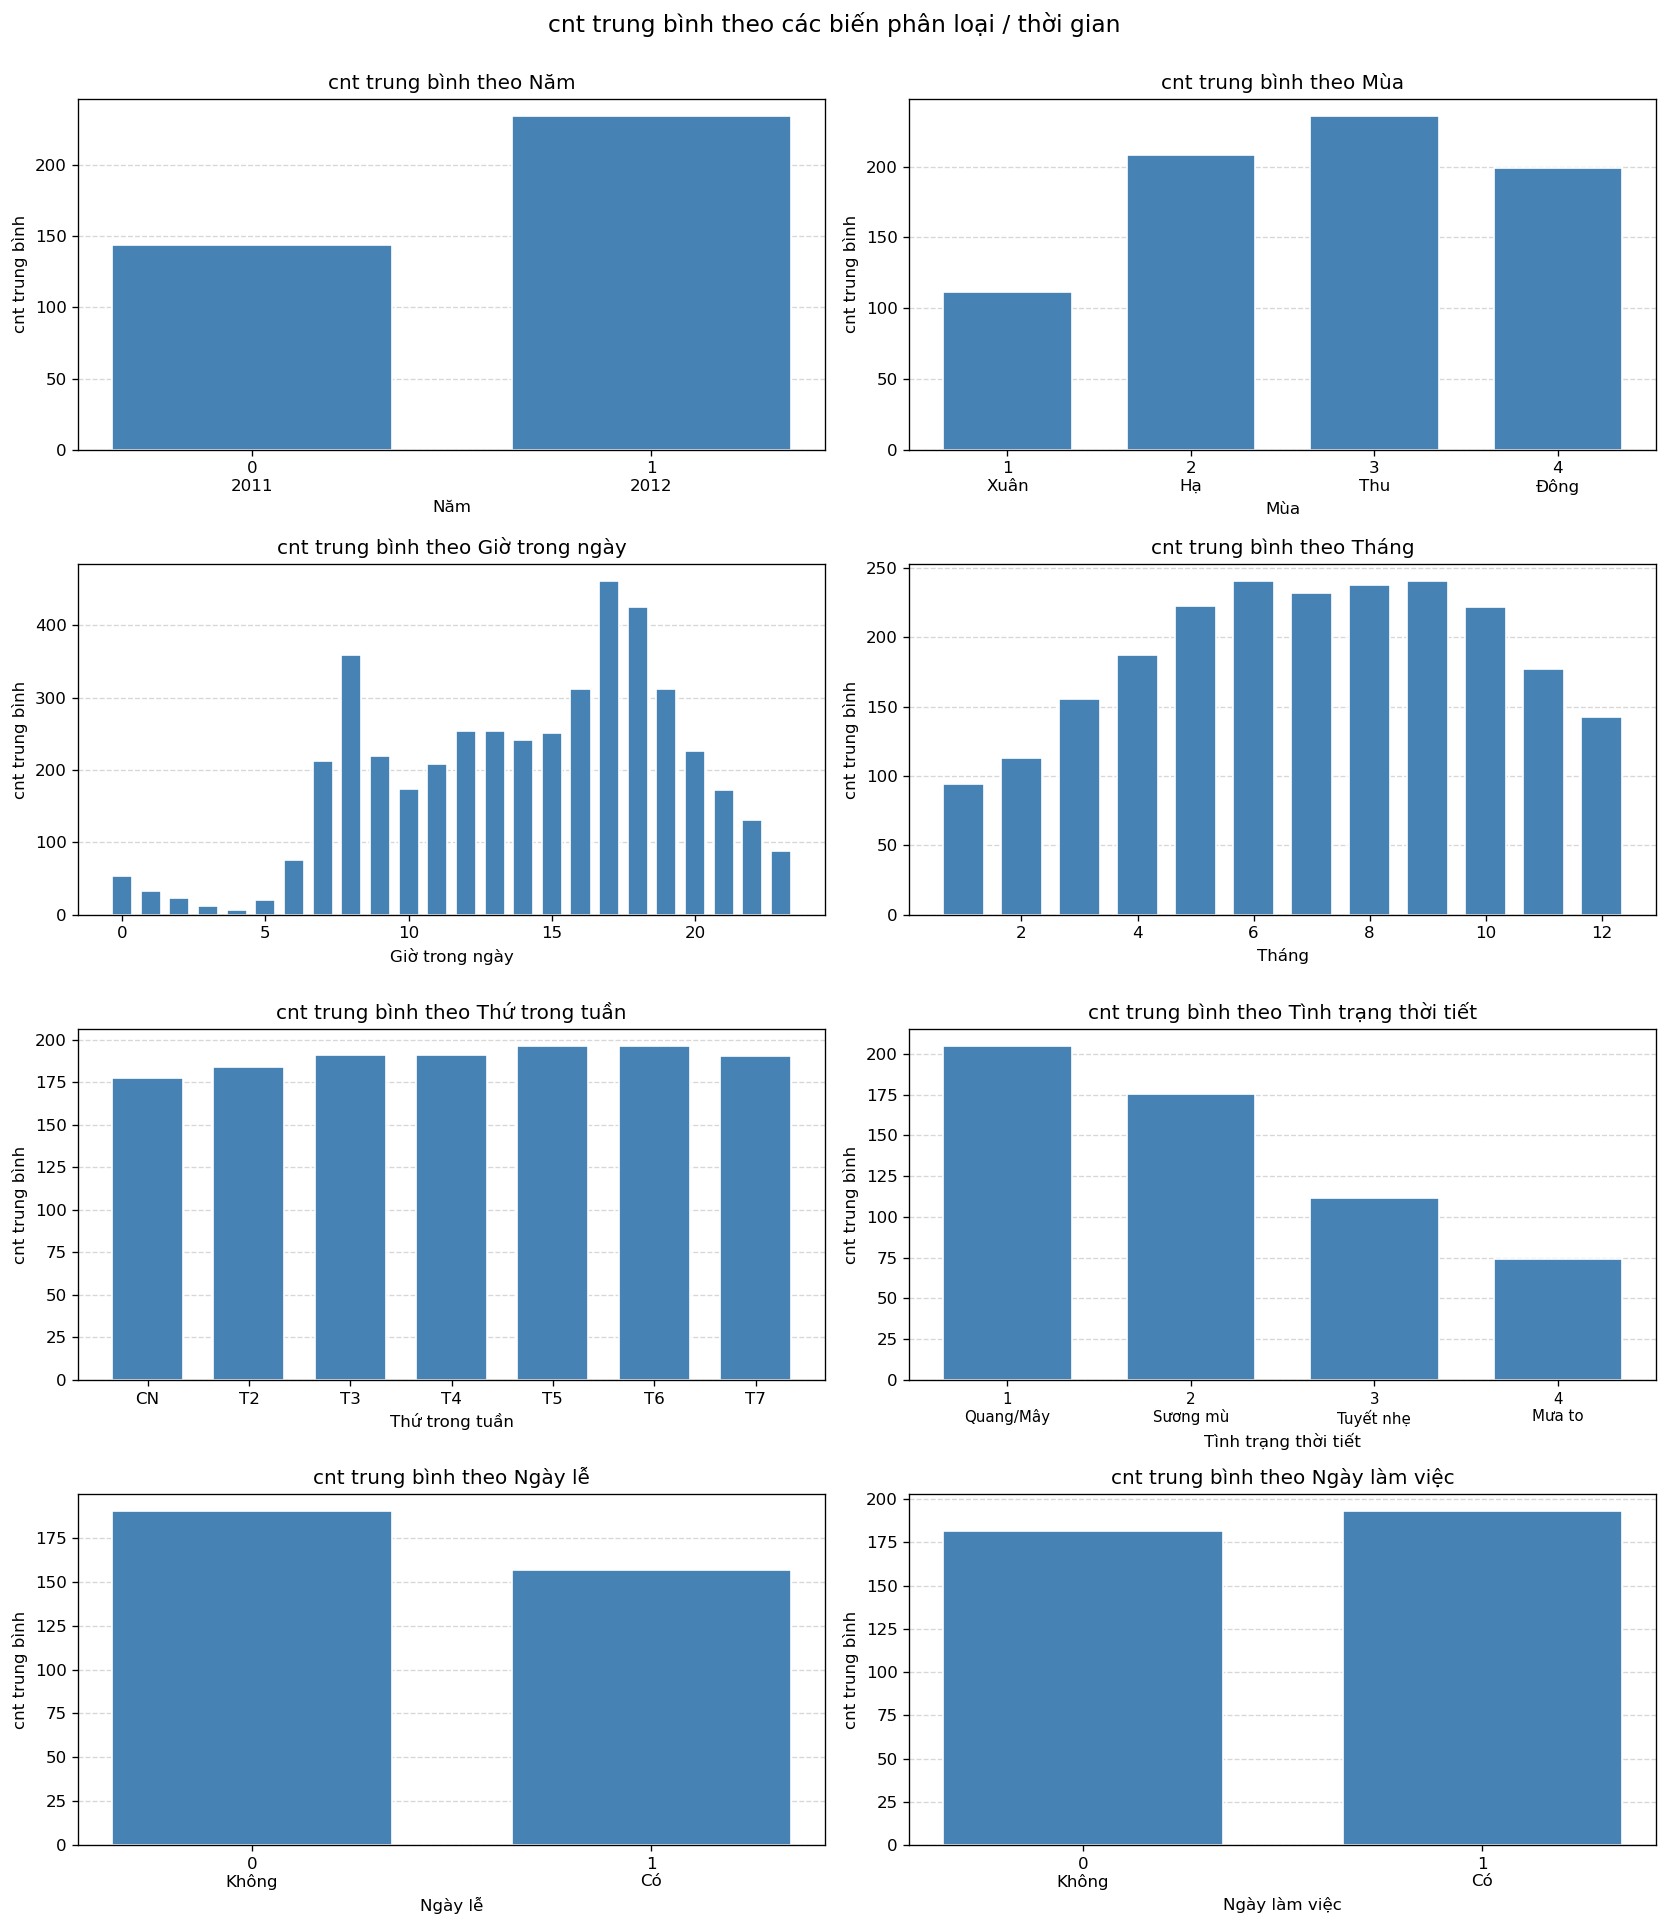

In [11]:
cat_vars = {
    "yr":         "Năm",
    "season":     "Mùa",
    "hr":         "Giờ trong ngày",
    "mnth":       "Tháng",
    "weekday":    "Thứ trong tuần",
    "weathersit": "Tình trạng thời tiết",
    "holiday":    "Ngày lễ",
    "workingday": "Ngày làm việc",
}

weekday_labels  = ["CN", "T2", "T3", "T4", "T5", "T6", "T7"]
weather_labels  = ["1\nQuang/Mây", "2\nSương mù", "3\nTuyết nhẹ", "4\nMưa to"]
season_labels   = ["1\nXuân", "2\nHạ", "3\nThu", "4\nĐông"]
binary_labels   = {
    "yr":         ["0\n2011", "1\n2012"],
    "holiday":    ["0\nKhông", "1\nCó"],
    "workingday": ["0\nKhông", "1\nCó"],
}

# Tăng lên 4 hàng 2 cột để chứa đủ 8 biến
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for ax, (var, title) in zip(axes.flat, cat_vars.items()):
    group = df.groupby(var)[TARGET].mean()
    bars = ax.bar(group.index, group.values, color="steelblue", edgecolor="white", width=0.7)

    # Tuỳ chỉnh nhãn trục x
    if var == "weekday":
        ax.set_xticks(range(7))
        ax.set_xticklabels(weekday_labels)
    elif var == "weathersit":
        ax.set_xticks([1, 2, 3, 4])
        ax.set_xticklabels(weather_labels, fontsize=9)
    elif var == "season":
        ax.set_xticks([1, 2, 3, 4])
        ax.set_xticklabels(season_labels)
    elif var in binary_labels:
        ax.set_xticks([0, 1])
        ax.set_xticklabels(binary_labels[var])

    ax.set_title(f"cnt trung bình theo {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("cnt trung bình")
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

plt.suptitle("cnt trung bình theo các biến phân loại / thời gian", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(IMGS_DIR / "cnt_by_categorical.png", bbox_inches="tight")
plt.show()

**Nhận xét**

- **`yr` (Năm):** Tăng mạnh từ 2011 (~150) lên 2012 (~230), tăng ~53%.

- **`season` (Mùa):** Mùa hè và mùa thu cao hơn đáng kể (>200) so với mùa đông và mùa xuân. Có hiện tượng lạ là mùa xuân thấp hơn mùa đông.

- **`hr` (Giờ trong ngày):** Phân bố hai đỉnh rõ rệt — đỉnh buổi sáng lúc 8h (~350) và đỉnh buổi chiều 17–18h (~460). Đây là hành vi commute điển hình. Từ 0–5h sáng gần như không có thuê xe (<60). `hr` là biến phân loại có ảnh hưởng lớn nhất đến `cnt`.

- **`mnth` (Tháng):** Nhu cầu tăng từ tháng 1 (~95) đến đỉnh tháng 6–10 (~230–245), sau đó giảm dần. Phản ánh rõ yếu tố mùa — mùa đông lạnh ở Washington D.C. làm giảm nhu cầu đáng kể.

- **`weekday` (Thứ trong tuần):** Chênh lệch rất nhỏ giữa các ngày (~175–200). Chủ nhật thấp nhất (~175), các ngày trong tuần cao hơn một chút — xe đạp được sử dụng cả cho commute lẫn giải trí.

- **`weathersit` (Tình trạng thời tiết):** Giảm đơn điệu rõ rệt theo mức độ xấu của thời tiết: Quang/Mây (~205) → Sương mù (~172) → Tuyết nhẹ (~112) → Mưa to (~70). Mưa to làm giảm hơn **65%** so với trời quang — tác động mạnh nhất trong nhóm biến phân loại.

- **`holiday` (Ngày lễ):** Ngày lễ thấp hơn ngày thường (~157 so với ~185, giảm ~15%) do mất lưu lượng commute trong khi người dùng giải trí không bù đắp đủ.

- **`workingday` (Ngày làm việc):** Cao hơn nhẹ so với ngày nghỉ (~192 so với ~178, ~8%) — nhất quán với quan sát từ `holiday`.

## 7. Phân tích time series

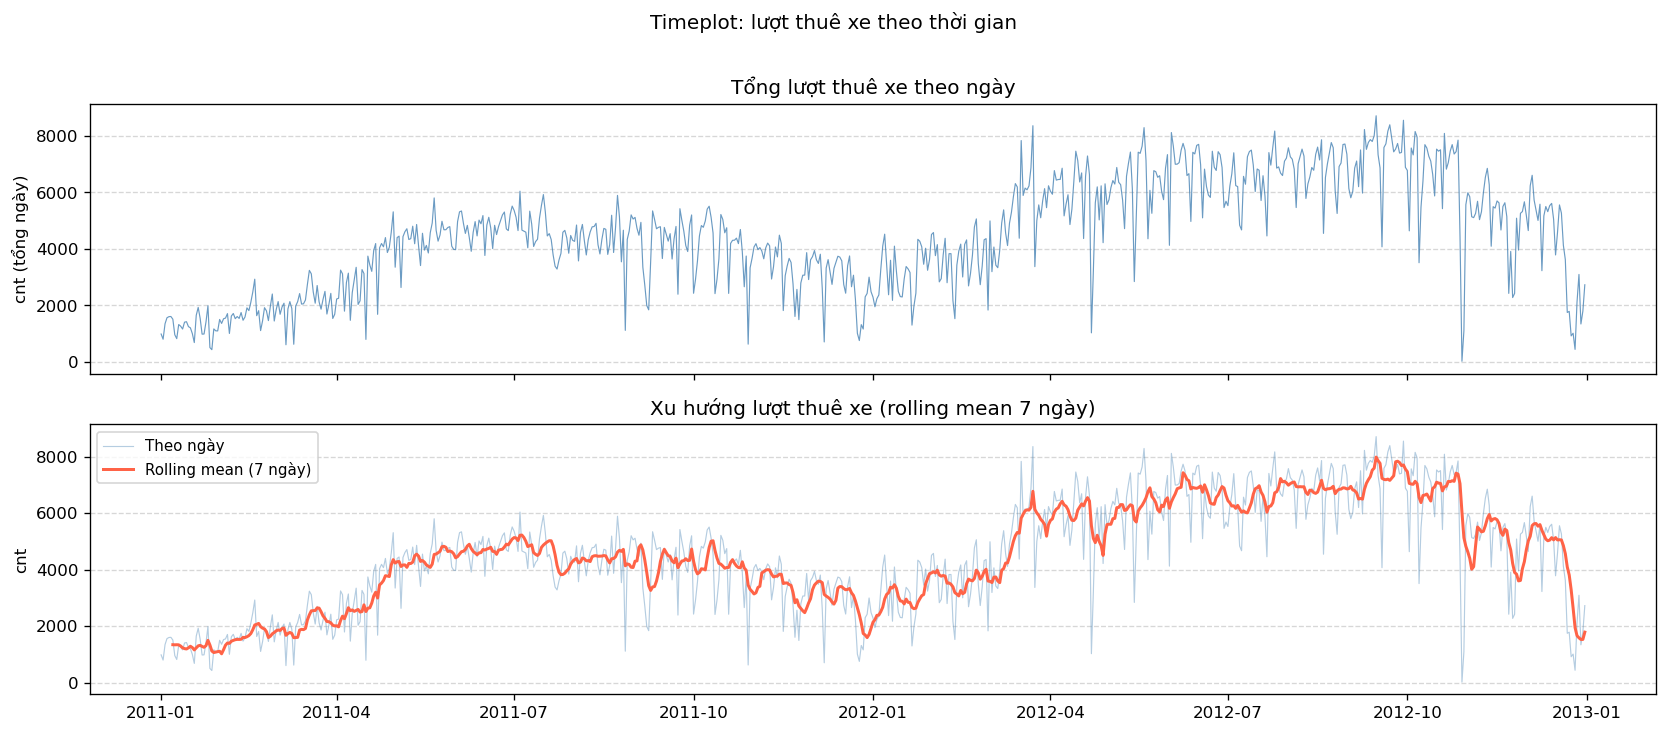

In [12]:
# Tạo time series với datetime index
df_ts = df.copy()
df_ts["datetime"] = pd.to_datetime(df_ts["dteday"]) + pd.to_timedelta(df_ts["hr"], unit="h")
df_ts = df_ts.set_index("datetime").sort_index()

# Resample theo ngày
daily = df_ts["cnt"].resample("D").sum()
rolling7 = daily.rolling(7).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(daily.index, daily.values, color="steelblue", linewidth=0.7, alpha=0.8)
axes[0].set_title("Tổng lượt thuê xe theo ngày")
axes[0].set_ylabel("cnt (tổng ngày)")
axes[0].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[0].set_axisbelow(True)

axes[1].plot(daily.index, daily.values,
             color="steelblue", linewidth=0.7, alpha=0.4, label="Theo ngày")
axes[1].plot(rolling7.index, rolling7.values,
             color="tomato", linewidth=1.8, label="Rolling mean (7 ngày)")
axes[1].set_title("Xu hướng lượt thuê xe (rolling mean 7 ngày)")
axes[1].set_ylabel("cnt")
axes[1].legend(fontsize=9)
axes[1].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[1].set_axisbelow(True)

plt.suptitle("Timeplot: lượt thuê xe theo thời gian", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(IMGS_DIR / "timeplot.png", bbox_inches="tight")
plt.show()

**Nhận xét**

- Chuỗi thời gian cho thấy **xu hướng tăng rõ rệt** từ 2011 sang 2012 — lượt thuê xe tăng gần gấp đôi, phản ánh sự phát triển của hệ thống Capital Bikeshare.
- Rolling mean 7 ngày làm nổi bật **tính mùa vụ hàng năm**: đỉnh vào mùa hè (tháng 6–9), đáy vào mùa đông (tháng 12–2).
- Biên độ dao động trong ngắn hạn lớn (dao động ngày trong tuần vs. cuối tuần, ảnh hưởng thời tiết).


## 8. Phát hiện outliers

### IQR

                Q1        Q3       IQR  Ngưỡng dưới  Ngưỡng trên  # Outliers  % Outliers
temp        0.3400    0.6600    0.3200     -0.14000      1.14000         0.0        0.00
atemp       0.3333    0.6212    0.2879     -0.09855      1.05305         0.0        0.00
hum         0.4800    0.7800    0.3000      0.03000      1.23000        22.0        0.13
windspeed   0.1045    0.2537    0.1492     -0.11930      0.47750       342.0        1.97
cnt        40.0000  281.0000  241.0000   -321.50000    642.50000       505.0        2.91


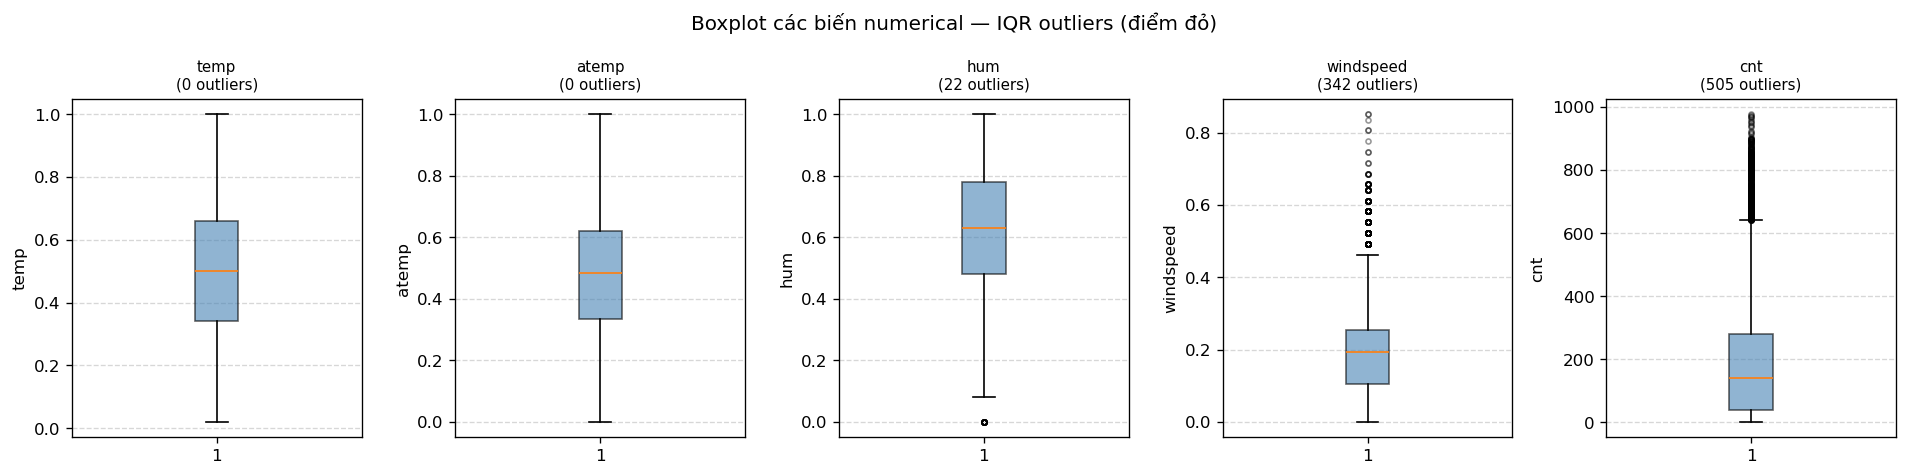

In [13]:
num_cols_outlier = ["temp", "atemp", "hum", "windspeed", TARGET]

# Tính IQR bounds và mask cho từng biến
iqr_results = {}
for col in num_cols_outlier:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    mask = (df[col] < lo) | (df[col] > hi)
    iqr_results[col] = {"q1": q1, "q3": q3, "iqr": iqr,
                        "lo": lo, "hi": hi, "mask": mask}

# Bảng tóm tắt
summary_iqr = pd.DataFrame({
    col: {
        "Q1":            v["q1"],
        "Q3":            v["q3"],
        "IQR":           v["iqr"],
        "Ngưỡng dưới":  v["lo"],
        "Ngưỡng trên":  v["hi"],
        "# Outliers":   int(v["mask"].sum()),
        "% Outliers":   round(v["mask"].mean() * 100, 2),
    }
    for col, v in iqr_results.items()
}).T
print(summary_iqr.to_string())

# Dùng mask_iqr của cnt cho các bước so sánh phía sau
q1_cnt = iqr_results[TARGET]["q1"]
hi_iqr = iqr_results[TARGET]["hi"]
mask_iqr = iqr_results[TARGET]["mask"]

# Boxplot toàn bộ biến numerical (outliers tô màu đỏ tự động)
fig, axes = plt.subplots(1, len(num_cols_outlier), figsize=(16, 4))
for ax, col in zip(axes, num_cols_outlier):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6),
               flierprops=dict(marker="o", color="tomato", alpha=0.4, markersize=3))
    n_out = int(iqr_results[col]["mask"].sum())
    ax.set_title(f"{col}\n({n_out} outliers)", fontsize=9)
    ax.set_ylabel(col)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

plt.suptitle("Boxplot các biến numerical — IQR outliers (điểm đỏ)", fontsize=12)
plt.tight_layout()
plt.savefig(IMGS_DIR / "outliers_boxplot.png", bbox_inches="tight")
plt.show()

**Nhận xét**

- **`temp`, `atemp`**: ngưỡng IQR vượt ra ngoài khoảng [0, 1] ở cả hai phía → **không có outlier**; phân bố trải đều trong toàn miền giá trị.
- **`hum`**: xuất hiện **outlier phía dưới** (hum ≈ 0) — nhiều khả năng là lỗi cảm biến hoặc thiếu dữ liệu đo lường, không phản ánh điều kiện thực tế.
- **`windspeed`**: có **outlier phía trên** (windspeed > 0.48) — các giờ có gió rất mạnh, hiếm gặp nhưng hoàn toàn có thể xảy ra trong thực tế.
- **`cnt`**: ngưỡng dưới âm → **không có outlier phía dưới**; outlier phía trên (cnt > 642.5) tương ứng với các giờ cao điểm mùa hè — hợp lệ về mặt nghiệp vụ, không nên loại bỏ.

**Kiểm tra một số outliers**

In [14]:
# Kiểm tra một số entry outliers 
outliers_cnt = df[mask_iqr][TARGET]
print("Một số outliers của cnt (IQR):")
print(df.loc[mask_iqr].head(5).to_string())

outliers_hum = df[iqr_results["hum"]["mask"]]["hum"]
print("\nMột số outliers của hum (IQR):")
print(df.loc[iqr_results["hum"]["mask"]].head(5).to_string())

outliers_windspeed = df[iqr_results["windspeed"]["mask"]]["windspeed"]
print("\nMột số outliers của windspeed (IQR):")
print(df.loc[iqr_results["windspeed"]["mask"]].head(5).to_string())


Một số outliers của cnt (IQR):
       instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp   atemp   hum  windspeed  casual  registered  cnt
5536      5537  2011-08-23       3   0     8  14        0        2           1           1  0.72  0.6515  0.30     0.0896     149         502  651
10358    10359  2012-03-12       1   1     3  17        0        1           1           2  0.62  0.6212  0.38     0.4179      87         557  644
10359    10360  2012-03-12       1   1     3  18        0        1           1           2  0.60  0.6212  0.43     0.1940      89         623  712
10382    10383  2012-03-13       1   1     3  17        0        2           1           1  0.70  0.6364  0.37     0.1045      62         614  676
10383    10384  2012-03-13       1   1     3  18        0        2           1           1  0.70  0.6364  0.34     0.2985      96         638  734

Một số outliers của hum (IQR):
      instant      dteday  season  yr  mnth  hr  holida

### Isolation Forest

Contamination 0.01: 174 outliers (1.00%)


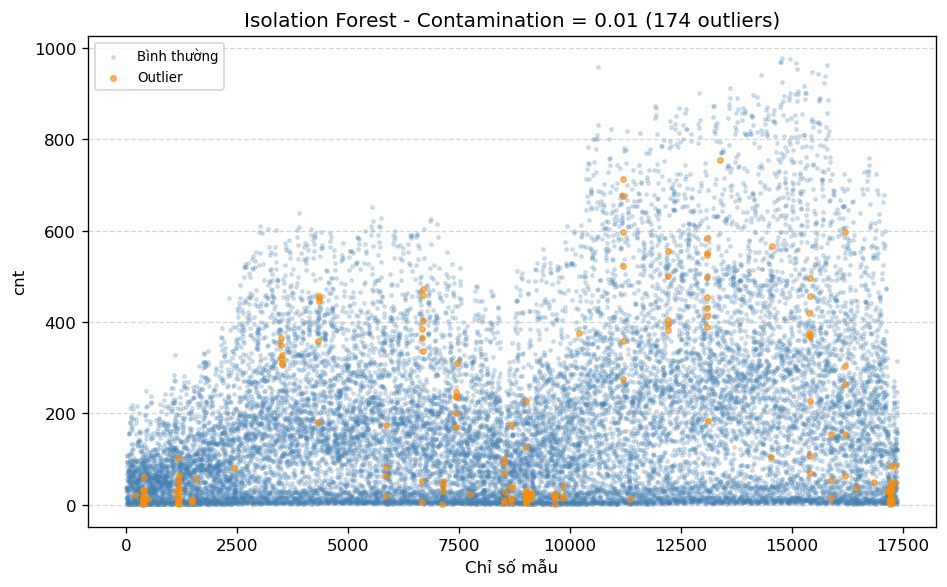

Contamination 0.05: 869 outliers (5.00%)


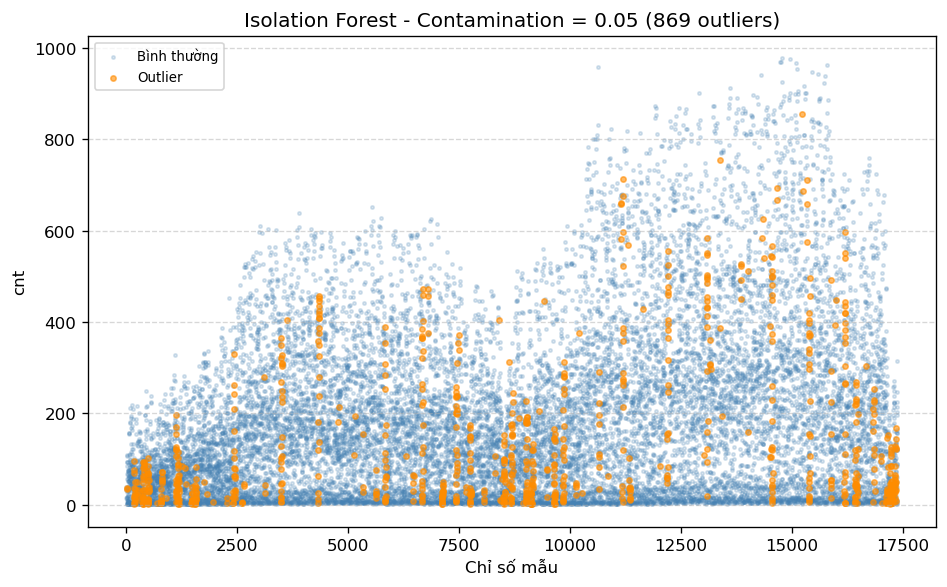

Contamination 0.1: 1738 outliers (10.00%)


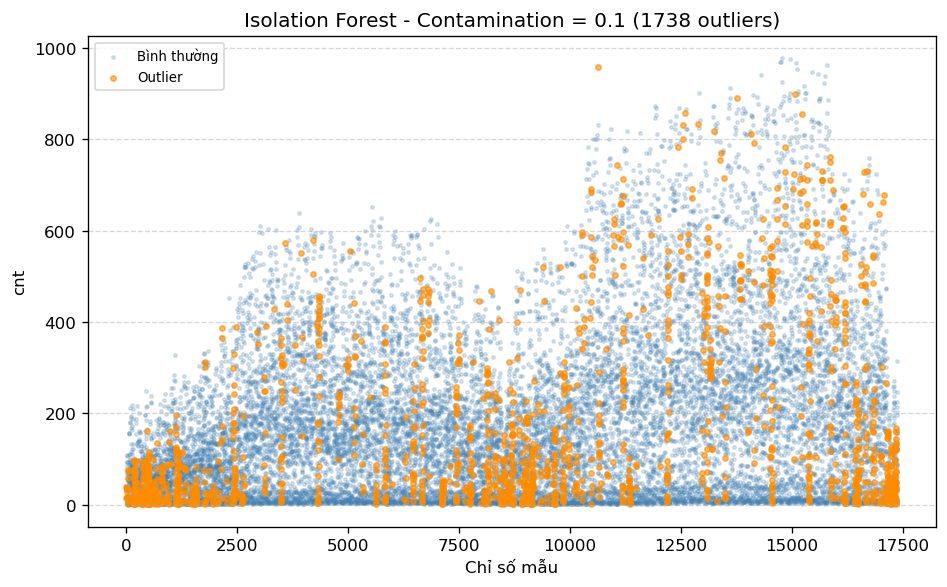

In [15]:
from sklearn.ensemble import IsolationForest

feat_if = FEATURES + [TARGET]
X_if = df[feat_if].copy()

contaminations = [0.01, 0.05, 0.1]

for cont in contaminations:
    # Huấn luyện mô hình
    iso = IsolationForest(n_estimators=200, contamination=cont, random_state=42)
    mask_if = iso.fit_predict(X_if) == -1
    
    # In kết quả
    print(f"Contamination {cont}: {mask_if.sum()} outliers ({(mask_if.mean()*100):.2f}%)")
    
    # Tạo figure mới cho từng biểu đồ
    plt.figure(figsize=(8, 5))
    
    plt.scatter(df.index[~mask_if], df.loc[~mask_if, TARGET],
               alpha=0.2, s=4, color="steelblue", label="Bình thường")
    plt.scatter(df.index[mask_if], df.loc[mask_if, TARGET],
               alpha=0.6, s=10, color="darkorange", label="Outlier")
    
    plt.title(f"Isolation Forest - Contamination = {cont} ({mask_if.sum()} outliers)")
    plt.xlabel("Chỉ số mẫu")
    plt.ylabel("cnt")
    plt.legend(fontsize=8)
    plt.grid(axis='y', linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

**Nhận xét**

Isolation Forest phát hiện outlier **đa biến** dựa trên toàn bộ không gian đặc trưng (12 features + `cnt`) — không chỉ xét riêng giá trị `cnt` mà còn xét tính bất thường của một mẫu trong ngữ cảnh tổ hợp nhiều biến (ví dụ: cnt cao nhưng thời tiết xấu, hoặc cnt thấp vào giờ cao điểm).

**Ảnh hưởng của `contamination`:**
- **`0.01` (~174 mẫu):** Chỉ đánh dấu các mẫu cô lập nhất — phần lớn là `cnt` cực cao ở đuôi phân bố, kết quả gần tương đồng với IQR.
- **`0.05` (~869 mẫu):** Bắt đầu phát hiện thêm các bất thường **theo ngữ cảnh** — nhiều mẫu có `cnt` trung bình nhưng bất thường về tổ hợp feature (giờ, thời tiết, mùa).
- **`0.10` (~1738 mẫu):** Đánh dấu quá nhiều, có khả năng bao gồm các mẫu hợp lệ về nghiệp vụ — mức này quá aggressive cho bộ dữ liệu có phân bố tự nhiên đa dạng.

**So sánh với IQR:** Outlier của IF **không tập trung ở `cnt` cao** mà phân bố rải rác — xác nhận IF bắt được các bất thường mà IQR (univariate) bỏ sót.

## Kết luận

### Chất lượng dữ liệu
- Không có missing values trong tập dữ liệu.
- Cần loại bỏ casual và registered để tránh data leakage vì hai biến này là thành phần trực tiếp của cnt.
- instant chỉ là chỉ số dòng, không mang ý nghĩa dự báo.
- dteday không cần giữ nguyên dạng thô cho mô hình cơ bản vì thông tin thời gian đã được tách sẵn qua yr, mnth, hr, weekday, season.

### Phát hiện chính từ EDA
- cnt có phân bố lệch phải mạnh, phần lớn quan sát nằm ở mức thấp đến trung bình và có đuôi dài ở nhóm giờ cao điểm.
- temp và atemp có tương quan dương mức vừa với cnt, nhưng temp và atemp gần như trùng thông tin nên cần tránh dùng đồng thời trong mô hình tuyến tính.
- hum có tương quan âm đáng kể với cnt; windspeed có tương quan tuyến tính yếu.
- Trong nhóm biến phân loại, hr là biến có mức liên hệ mạnh nhất với cnt; tiếp theo là các yếu tố mùa vụ như mnth, season, yr.
- weathersit có xu hướng làm giảm cnt khi thời tiết xấu đi, nhưng mức tương quan đơn biến không mạnh.

### Tính thời gian và mùa vụ
- Chuỗi thời gian cho thấy xu hướng tăng nhu cầu từ 2011 sang 2012.
- Có mùa vụ rõ rệt theo năm: cao ở giai đoạn ấm, thấp ở mùa lạnh.
- Dao động ngắn hạn lớn, phản ánh ảnh hưởng đồng thời của ngày trong tuần, giờ trong ngày và điều kiện thời tiết.

### Outlier
- IQR chủ yếu phát hiện outlier ở đuôi cao của cnt và một phần nhỏ ở hum, windspeed.
- Isolation Forest phát hiện thêm các điểm bất thường theo ngữ cảnh đa biến, không chỉ theo độ lớn cnt.
- Nhiều outlier cnt cao là hợp lệ về nghiệp vụ (giờ cao điểm), không nên loại bỏ máy móc.